In [2]:
import numpy as np
import scipp as sc
import MDAnalysis as mda
from MDAnalysis.coordinates.memory import MemoryReader
from kinisi.analyze import DiffusionAnalyzer
from tqdm import tqdm
from pathlib import Path

In [3]:
def walk(atoms, timesteps, jump_size, seed):
    possible_moves = np.zeros((6, 3))

    j = 0

    for i in range(0, 6, 2):

        possible_moves[i, j] = jump_size

        possible_moves[i + 1, j] = -jump_size

        j += 1
    choices = seed.choice(6, size=(atoms, timesteps))

    steps = possible_moves[choices]

    return np.cumsum(steps, axis=1)

In [4]:
def raw_covariance(d):

    da = d.dg['da']

    variances = da.data.variances

    n_samples = da.coords['n_samples'].values

    n = variances.size

    cov = np.zeros((n, n))

    for i in range(n):

        for j in range(i, n):

            ratio = n_samples[i] / n_samples[j]

            cov[i, j] = ratio * variances[i]

            cov[j, i] = cov[i, j]

    regime = d.diff.diff_regime
    
    return cov[regime:, regime:]

In [ ]:
data = Path.home() / "Desktop" / "Dissertation" / "kappa-kinisi" / "data"

data.mkdir(parents=True, exist_ok=True)


step = 1

length = int(2 ** 7)

atoms = int(2 ** 7)

jump = np.sqrt(6)

size = int(2 ** 12)



D = np.zeros((size, 3200))

cov = np.zeros((size, (length - 2) // step, (length - 2) // step))

msd = np.zeros((size, (length - 2) // step, 4))



for i in tqdm(range(size)):
    rng = np.random.RandomState(i)

    steps = walk(atoms, length, jump, rng)

    dims = np.tile([200.0, 200.0, 200.0, 90.0, 90.0, 90.0], (steps.shape[1], 1))

    u = mda.Universe.empty(steps.shape[0], trajectory=True)
    u.add_TopologyAttr('name', [f'Atom{k}' for k in range(steps.shape[0])])
    u.add_TopologyAttr('type', ['A'] * steps.shape[0])
    u.trajectory = MemoryReader(np.transpose(steps, (1, 0, 2)), dimensions=dims, delta=1.0)

    
    d = DiffusionAnalyzer.from_universe(
        u, time_step=1.0 * sc.Unit('s'), step_skip=1,
        distance_unit=sc.Unit('m'), specie='A',
        dt=sc.linspace(dim='time interval', start=2 * sc.Unit('s'),
                       stop=length * sc.Unit('s'), num=int((length - 2) / step)),
        progress=False)
    

    d.diffusion(2 * sc.Unit('s'), progress=False)


    D[i, :] = d.D.values

    cov[i, :, :] = raw_covariance(d)

    msd[i, :, 0] = d.dt.values

    msd[i, :, 1] = d.msd.values

    msd[i, :, 2] = d.msd.variances

    msd[i, :, 3] = d.da.coords['n_samples'].values

np.savez_compressed(data / f'kinisi_rw_data_{step}.npz', D=D, cov=cov, msd=msd)

print("saved", data / f'kinisi_rw_data_{step}.npz')

In [6]:
base = Path.home() / "Desktop" / "Dissertation" / "kappa-kinisi"

d = np.load(base / "data" / "kinisi_rw_data_1.npz")

cov = d["cov"]

msd = d["msd"]


length = 128

dimensionality = 3

D = 6 / (dimensionality * 2)

timestep = msd[0, :, 0]

no = msd[0, :, 3]

anal_cov = np.zeros((no.shape[0], no.shape[0]))

for i in range(anal_cov.shape[0]):

    for j in range(i, anal_cov.shape[1]):

        anal_cov[i, j] = 8 * dimensionality**2 * D**2 * timestep[i]**2 / (dimensionality * no[j])

        anal_cov[j, i] = anal_cov[i, j]

print("sample cov shape:", cov.shape)

print("analytical cov shape:", anal_cov.shape)

sample cov shape: (4096, 126, 126)
analytical cov shape: (126, 126)


In [ ]:
a = np.array([[2.0, 1.0],
              [1.0, 2.0]])   # symmetric

print("eig:")
vals, vecs = np.linalg.eig(a)
print("  eigenvalues:", vals)        # returns vals ad  vecs, maybe unsorted

print("eigvalsh:")
vals_h = np.linalg.eigvalsh(a)
print("  eigenvalues:", vals_h)

eig:
  eigenvalues: [3. 1.]
eigvalsh:
  eigenvalues: [1. 3.]


In [8]:
base = Path.home() / "Desktop" / "Dissertation" / "kappa-kinisi"

d = np.load(base / "data" / "kinisi_rw_data_1.npz")

cov = d["cov"]

max_diff = 0.0
for k in range(cov.shape[0]):
    a = np.linalg.eigvalsh(cov[k])
    b = np.linalg.eigh(cov[k])[0]
    max_diff = max(max_diff, np.max(np.abs(a - b)))

print("difference:", max_diff)

print("all are same ?", max_diff < 1e-9)

difference: 2.9103830456733704e-10
all are same ? True


In [9]:
ev = np.linalg.eigvalsh(cov)
lam_min = ev[:, 0]
lam_max = ev[:, -1]

anal_ev = np.linalg.eigvalsh(anal_cov)
anal_min = anal_ev[0]
anal_max = anal_ev[-1]



print("lambda max")
print("  analytical:   ", anal_max)
print("  sample mean:  ", lam_max.mean())
print("  sample median:", np.median(lam_max))


print()


print("lambda min")
print("  analytical:   ", anal_min)
print("  sample mean:  ", lam_min.mean())
print("  sample median:", np.median(lam_min))
print("  sample min:   ", lam_min.min())
print("  fraction negative:", np.mean(lam_min < 0))
print()
print("analytical condition number:", anal_max / anal_min)

lambda max
  analytical:    86416.95935575101
  sample mean:   85096.67383508504
  sample median: 83657.14098340823

lambda min
  analytical:    0.003002671689125021
  sample mean:   -96.8605440970602
  sample median: -26.653716901812835
  sample min:    -1923.107935882373
  fraction negative: 0.813720703125

analytical condition number: 28780022.69403383


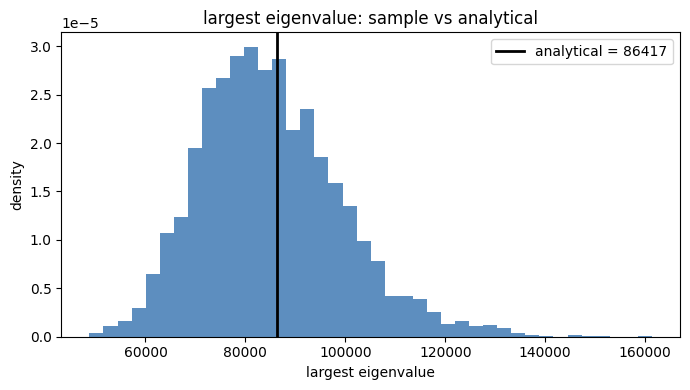

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(lam_max, density=True, bins=40, color="#185fa5", alpha=0.7)

ax.axvline(anal_max, color="k", linewidth=2, label=f"analytical = {anal_max:.0f}")

ax.set_xlabel("largest eigenvalue")

ax.set_ylabel("density")

ax.set_title("largest eigenvalue: sample vs analytical")

ax.legend()

plt.tight_layout()

plt.show()

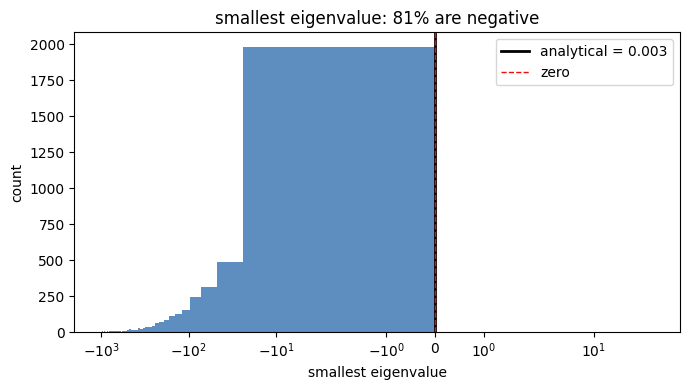

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(lam_min, bins=80, color="#185fa5", alpha=0.7)

ax.axvline(anal_min, color="k", linewidth=2, label=f"analytical = {anal_min:.3f}")

ax.axvline(0, color="#f20b0b", linewidth=1, linestyle="--", label="zero")

ax.set_xscale("symlog")

ax.set_xlabel("smallest eigenvalue")

ax.set_ylabel("count")

ax.set_title(f"smallest eigenvalue: {np.mean(lam_min < 0) * 100:.0f}% are negative")

ax.legend()
plt.tight_layout()

plt.show()

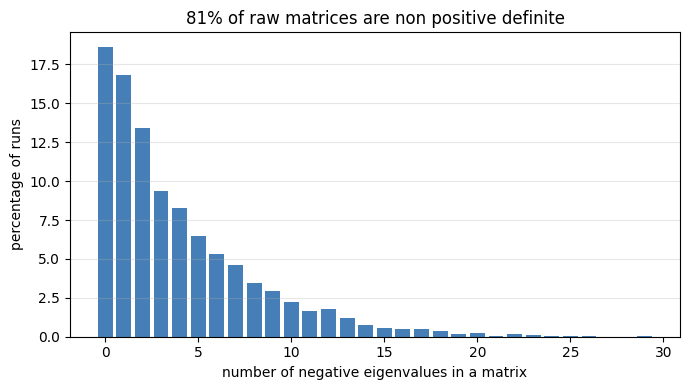

distribution of negative counts:
  0: 763 (18.6%)
  1: 690 (16.8%)
  2: 550 (13.4%)
  3: 384 (9.4%)
  4: 340 (8.3%)
  5: 266 (6.5%)
  6: 218 (5.3%)
  7: 188 (4.6%)
  8: 142 (3.5%)
  9: 121 (3.0%)
  10: 92 (2.2%)
  11: 68 (1.7%)
  12: 74 (1.8%)
  13: 48 (1.2%)
  14: 31 (0.8%)
  15: 24 (0.6%)
  16: 20 (0.5%)
  17: 21 (0.5%)
  18: 16 (0.4%)
  19: 7 (0.2%)
  20: 11 (0.3%)
  21: 3 (0.1%)
  22: 6 (0.1%)
  23: 4 (0.1%)
  24: 3 (0.1%)
  25: 2 (0.0%)
  26: 2 (0.0%)
  29: 2 (0.0%)


In [14]:
n_neg = np.sum(ev < 0, axis=1)

counts = np.bincount(n_neg)

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(range(len(counts)), counts / len(n_neg) * 100, color="#185fa5", alpha=0.8)

ax.set_xlabel("number of negative eigenvalues in a matrix")

ax.set_ylabel("percentage of runs")

ax.set_title(f"{np.mean(n_neg >= 1) * 100:.0f}% of raw matrices are non positive definite")

ax.grid(alpha=0.3, axis="y")

plt.tight_layout()


plt.show()

print("distribution of negative counts:")

for k in range(len(counts)):
    
    if counts[k] > 0:
        print(f"  {k}: {counts[k]} ({counts[k] / len(n_neg) * 100:.1f}%)")